# E-Commerce Dashboard — Exploratory Data Analysis

This notebook explores the Brazilian e-commerce dataset (Olist) to understand sales trends, product performance, and customer behaviour before building the Streamlit dashboard.

---
## Section 1: Data Loading & Overview

We load several CSV files that together describe the full order lifecycle:

| File | What it contains |
|------|------------------|
| `olist_orders_dataset.csv` | One row per order — status, timestamps, customer ID |
| `olist_order_items_dataset.csv` | Line items: which product, seller, price, freight |
| `olist_products_dataset.csv` | Product metadata: category, dimensions, description length |
| `olist_customers_dataset.csv` | Customer city/state and a unique customer key |
| `olist_order_payments_dataset.csv` | Payment method, installments, and payment value per order |
| `product_category_name_translation.csv` | Maps Portuguese category names to English |

The central table is **orders**. Items join to it on `order_id`; products join to items on `product_id`; customers join to orders on `customer_id`; reviews join to orders on `order_id`.

In [35]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [36]:
DATA_DIR = Path.cwd().parent / "data"

def read_data(path : Path) -> pd.DataFrame:
    try: 
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        return None
    print(f"\n--- {path.name} ---\n")
    return df

#1 
orders = read_data(DATA_DIR / "olist_orders_dataset.csv")
print(orders.shape)
orders.info()
print(orders.head())

#2
order_items = read_data(DATA_DIR / "olist_order_items_dataset.csv")
print(order_items.shape)
order_items.info()
print(order_items.head())

#3
products = read_data(DATA_DIR / "olist_products_dataset.csv")
print(products.shape)
products.info()
print(products.head())

#4
customers = read_data(DATA_DIR / "olist_customers_dataset.csv")
print(customers.shape)
customers.info()
print(customers.head())

#5
payments = read_data(DATA_DIR / "olist_order_payments_dataset.csv")
print(payments.shape)
payments.info()
print(payments.head())

#6
category_translation = read_data(DATA_DIR / "product_category_name_translation.csv")
print(category_translation.shape)
category_translation.info()
print(category_translation.head())

#7
reviews = read_data(DATA_DIR / "olist_order_reviews_dataset.csv")
print(reviews.shape)
reviews.info()
print(reviews.head())

print("All files loaded successfully")


--- olist_orders_dataset.csv ---

(99441, 8)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44

### Observations:

- `orders` — 99,441 rows, 8 columns. Central table — all other files connect to it via `order_id` or `customer_id`. Date columns loaded as strings and will need to be converted before any time-based analysis. The dataset spans 2016–2018.
- `order_items` — 112,650 rows, 7 columns. Contains line-item data per order: product, seller, price, and freight value. Row count exceeds orders because a single order can contain multiple products — each gets its own row.
- `products` — 32,951 rows, 9 columns. Contains product metadata including dimensions and category names in Portuguese. 610 rows have no category assigned — these will be dropped in preprocessing, as they represent less than 1% of the dataset.
- `customers`, `payments`, `category_translation` — all loaded cleanly with no missing values or structural issues.

---
## Section 2: Data Quality

Before any analysis we need to understand what is missing or malformed. We check:

- **Null values** — which columns have gaps and whether they are random or systematic (e.g. reviews only exist for delivered orders, so missing review scores on cancelled orders are expected).
- **Duplicates** — duplicate `order_id` rows in the orders table or duplicate `order_id + product_id` pairs in items would distort revenue figures.
- **Data types** — timestamp columns often arrive as plain strings; price and freight columns should be floats; category columns should be categorical. Wrong types cause silent errors downstream.

In [37]:
dataframes = {'customers': customers, 'order_items' : order_items, 
              'order_payments' : payments, 'orders' : orders,
               'products' : products, 'category_translation' : category_translation,
               'reviews': reviews}


for name,df in dataframes.items():
    print(f"DataFrame: {name}, Nan values count:\n {df.isna().sum()}, \nDuplicates count: {df.duplicated().sum()}\n")


DataFrame: customers, Nan values count:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64, 
Duplicates count: 0

DataFrame: order_items, Nan values count:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64, 
Duplicates count: 0

DataFrame: order_payments, Nan values count:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64, 
Duplicates count: 0

DataFrame: orders, Nan values count:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
ord

In [38]:
# Break down order statuses to understand why delivery date columns have NaN values
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Decisions:

- NaN values in orders (delivery date columns) belong to non-delivered orders (cancelled, shipped, processing, etc.). These will be removed in utils.py when we filter for delivered orders only.
- NaN values in products (category columns) will be dropped — they account for less than 1% of the dataset, so the data loss is negligible.
- No duplicates were found in any of the datasets.
- reviews dataset contains NaN values only in review_comment_title and review_comment_message — this is expected, as most customers leave a score without a written comment. review_score has no missing values and is ready to use

---
## Section 3: Time Analysis

We look at how the business grew over time. The dataset spans roughly 2016-2018. Key questions:

- Is revenue growing month-over-month, or are there seasonal dips?
- Do order volumes track revenue, or is average order value changing?
- Are there anomalous months (data gaps, promotional spikes) that need flagging before the ML section?

We aggregate to **monthly** granularity because daily data is too noisy for trend analysis and the ML section will also use monthly aggregates.

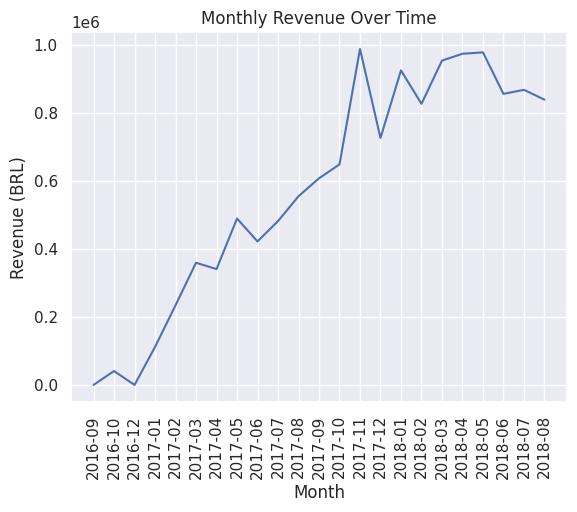

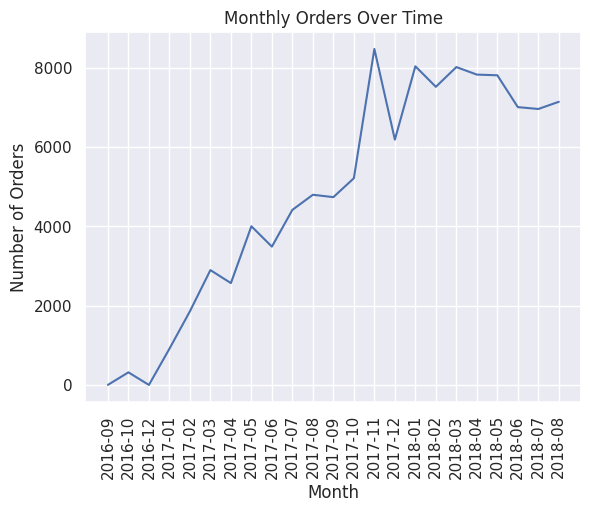

In [39]:
sns.set()

# Drop orders without a confirmed delivery date — these are non-delivered orders that would skew revenue figures
orders = orders.dropna(subset=['order_delivered_customer_date'])

# Left join to catch any delivered orders that have no matching line items — should not happen, but guards against data gaps
all_about_orders = orders.merge(order_items, on = 'order_id', how = 'left')
all_about_orders['order_purchase_timestamp'] = pd.to_datetime(all_about_orders['order_purchase_timestamp'])
# Period type allows grouping all days in a month under one label
all_about_orders['month'] = all_about_orders['order_purchase_timestamp'].dt.to_period('M')

# Sum price per month to get total revenue — not mean, because we want the full volume signal
monthly_revenue = all_about_orders.groupby('month', as_index = False)['price'].agg('sum')
# Convert Period to string so seaborn treats x-axis as categorical, preserving chronological order
monthly_revenue['month'] = monthly_revenue['month'].astype('str')

plt.figure()
sns.lineplot(monthly_revenue, x = 'month', y = 'price')
plt.xticks(rotation=90)
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)");


# Count distinct order_ids per month — not items — to measure demand volume independently of basket size
monthly_orders = all_about_orders.groupby('month', as_index = False)['order_id'].agg('count')
monthly_orders = monthly_orders.rename(columns = {'order_id':'orders_count'})
monthly_orders['month'] = monthly_orders['month'].astype('str')

plt.figure()
sns.lineplot(monthly_orders, x = 'month', y = 'orders_count')
plt.xticks(rotation=90)
plt.title("Monthly Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders");

### Observations

- Strong upward revenue trend from late 2016 through mid-2018
- Late 2016 data is incomplete — September and October have very low values, November and December are missing entirely, likely because the platform was just launching
- Revenue and order count follow almost identical patterns, meaning average order value stayed relatively stable over time
- A visible plateau and slight decline appears in mid-2018 — this could reflect market saturation or seasonal effects, but more data would be needed to confirm

---
## Section 4: Product Analysis

We examine the product catalogue to understand what sells and what drives satisfaction. Key questions:

- Which **categories** generate the most revenue and order volume?
- How are **prices** distributed within and across categories — are there outliers?
- Do **review scores** vary by category? Low-scoring categories are candidates for dashboard alerts.

This section informs which dimensions to expose as filters in the Streamlit dashboard.

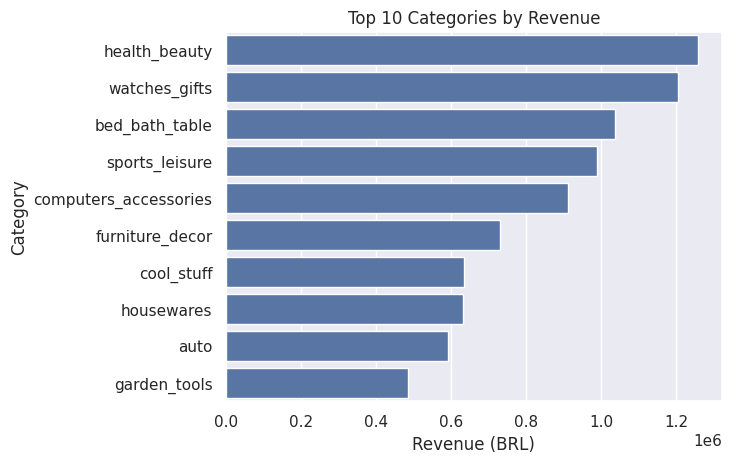

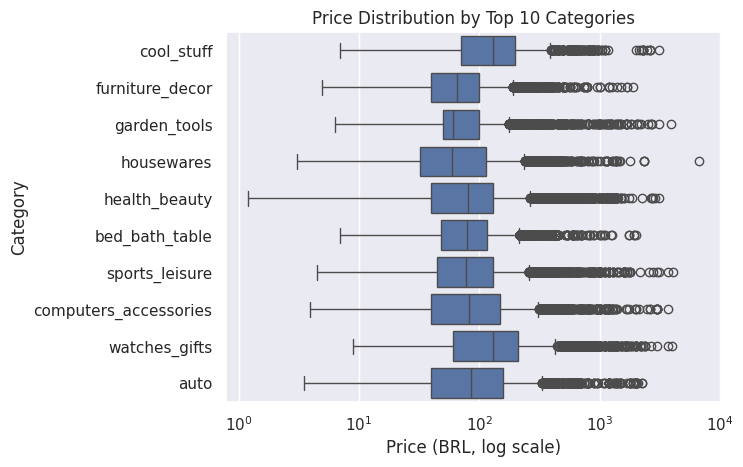

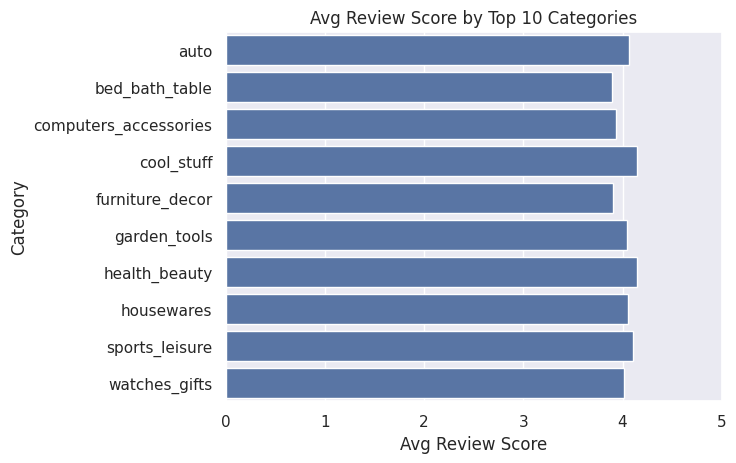

In [ ]:
# Bring English category names onto each line item so charts are readable without a lookup table
items_with_products = order_items.merge(products, on = 'product_id', how = 'left')
product_analysis = items_with_products.merge(category_translation, on = 'product_category_name', how = 'left')

# Sum revenue per category — not count — because a category with cheap high-volume items could rank differently by order count
sort_by_category = product_analysis.groupby('product_category_name_english', as_index = False)['price'].agg('sum')
# Limit to top 10 so the chart remains legible and we focus on commercially significant categories
top_10_categories = sort_by_category.sort_values(by = 'price', ascending = False).head(10)

plt.figure()
sns.barplot(data = top_10_categories, y = 'product_category_name_english', x = 'price')
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue (BRL)")
plt.ylabel("Category");

# Filter `product_analysis` to the top 10 only so the boxplot isn't cluttered by dozens of low-revenue categories
top_10_filtered = product_analysis[product_analysis['product_category_name_english'] \
                                   .isin(top_10_categories['product_category_name_english'])]

plt.figure()
sns.boxplot(data = top_10_filtered, x = 'price', y = 'product_category_name_english')
# Log scale compresses the long right tail so the bulk of the distribution is visible alongside extreme outliers
plt.xscale('log')
plt.title("Price Distribution by Top 10 Categories")
plt.xlabel("Price (BRL, log scale)")
plt.ylabel("Category");

# Join `reviews` onto `product_analysis` via `order_id` so each line item inherits the satisfaction score for its order
product_reviews = product_analysis.merge(reviews, on = 'order_id', how = 'left')
product_reviews = product_reviews[product_reviews['product_category_name_english'] \
                                    .isin(top_10_categories['product_category_name_english'])]

# Mean score per category — aggregating here rather than plotting raw rows avoids overweighting high-volume categories
reviews_by_categories = product_reviews.groupby('product_category_name_english', as_index = False)['review_score'].agg('mean')

plt.figure()
sns.barplot(data = reviews_by_categories, x = 'review_score', y = 'product_category_name_english')
plt.title("Avg Review Score by Top 10 Categories")
plt.xlabel("Avg Review Score")
plt.ylabel("Category")
# Fix x-axis to 0–5 so bars reflect the true scale of the rating system and differences aren't visually exaggerated
plt.xlim(0, 5);

### Observations

- `health_beauty` leads revenue among top 10 categories, followed by `watches_gifts` and `bed_bath_table`
- Price distributions are right-skewed across all categories — most products are low-priced with a long tail of expensive outliers; log scale was applied to reveal this
- Review scores are consistently high (~4.0/5.0) across all top 10 categories, suggesting customer satisfaction does not vary significantly by category

---
## Section 5: Customer Analysis

We profile the customer base along three dimensions:

- **Geography** — which Brazilian states and cities account for the most orders and revenue? This feeds the map visualisation in the dashboard.
- **Repeat customers** — what share of customers placed more than one order? High repeat rates suggest loyalty; low rates suggest acquisition-heavy growth.
- **Delivery time** — how many days between `order_purchase_timestamp` and `order_delivered_customer_date`? Long or variable delivery times correlate with low review scores and churn.

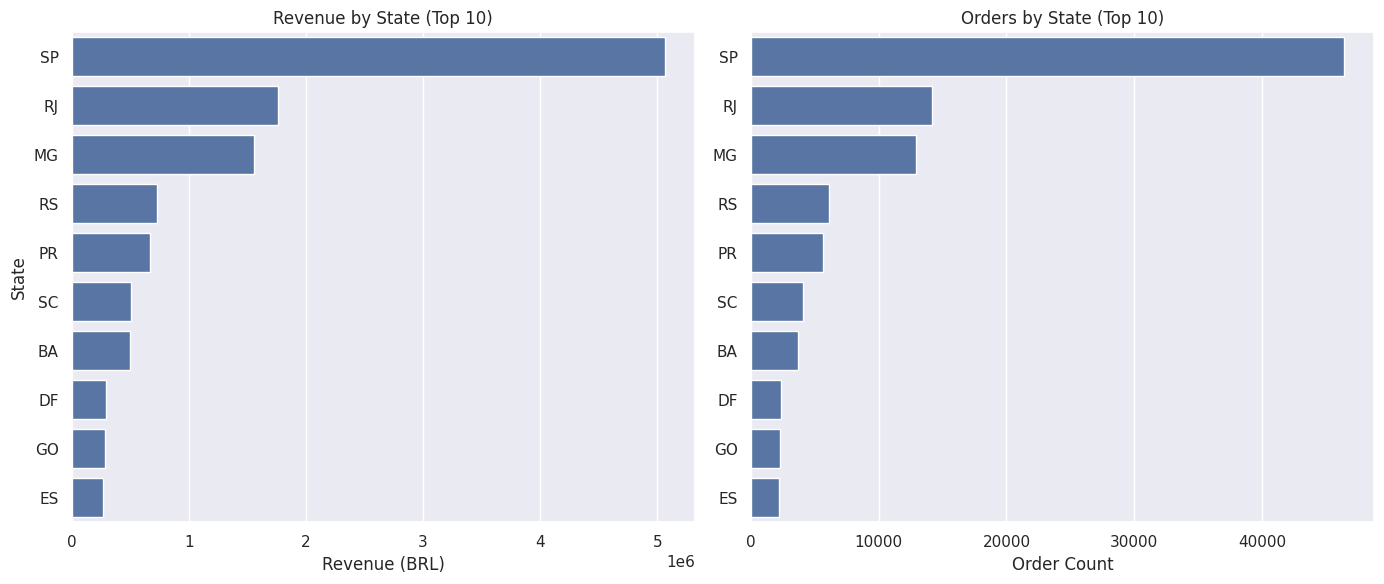

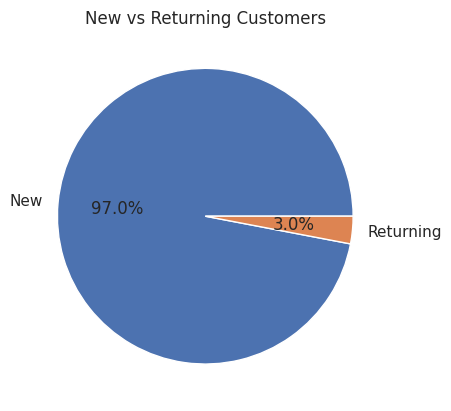

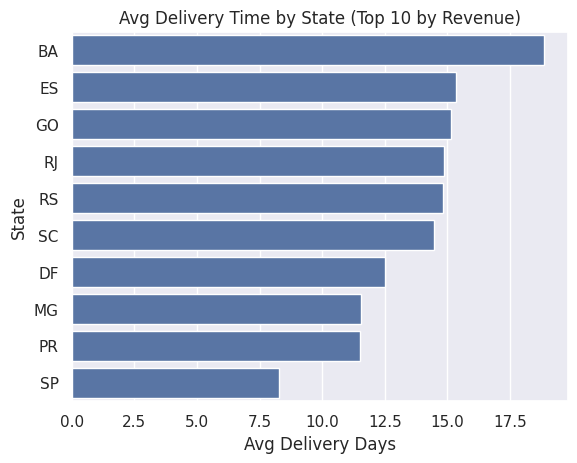

In [41]:
# Join customer state onto orders so geographic segmentation is possible — state isn't on the orders table directly
orders_geo = all_about_orders.merge(customers, on = 'customer_id', how = 'left')

# Single grouped aggregation captures both revenue and order count in one pass, avoiding a second groupby later
orders_geo = orders_geo.groupby('customer_state', as_index = False).agg(revenue = ('price', 'sum'), orders = ('order_id', 'count'))
# Sort by revenue first so both subplots share the same state ordering, making side-by-side comparison easier
top_10_orders_geo = orders_geo.sort_values(by = ['revenue', 'orders'], ascending = [False, False]).head(10)

# Side-by-side layout lets revenue and order count be compared directly without context-switching between separate figures
_, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data = top_10_orders_geo, x = 'revenue', y = 'customer_state', ax = ax[0])
ax[0].set_title("Revenue by State (Top 10)")
ax[0].set_xlabel("Revenue (BRL)")
ax[0].set_ylabel("State")

sns.barplot(data = top_10_orders_geo, x = 'orders', y = 'customer_state', ax = ax[1])
ax[1].set_title("Orders by State (Top 10)")
ax[1].set_xlabel("Order Count")
ax[1].set_ylabel("")

# Prevent subplot labels and titles from overlapping each other
plt.tight_layout();


# Use `customer_unique_id` rather than `customer_id` — a single person can have multiple `customer_id` values across orders
orders_customers = orders.merge(customers, on = 'customer_id', how = 'left')
repeat_analysis = orders_customers.groupby('customer_unique_id', as_index = False)['order_id'].agg('count')
# Binary label makes the pie chart immediately readable without needing to interpret raw counts
repeat_analysis['type'] = np.where(repeat_analysis['order_id'] > 1, 'Returning', 'New')

counts = repeat_analysis['type'].value_counts()

plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title("New vs Returning Customers")
plt.show()

# Convert to datetime here rather than at load time — delivery time is only meaningful in this geographic context
orders_customers[['order_purchase_timestamp', 'order_delivered_customer_date']] = \
    orders_customers[['order_purchase_timestamp', 'order_delivered_customer_date']].apply(pd.to_datetime)

# eval() computes the timedelta in a single readable expression without creating an intermediate column
timedelta = orders_customers.eval('order_delivered_customer_date - order_purchase_timestamp').dt.days
orders_customers['delivery_days'] = timedelta
# Drop rows where delivery date is missing — undelivered orders would pull the average down artificially
orders_customers = orders_customers.dropna()

# Mean delivery days per state — mean chosen over median so extreme delays (outliers) are reflected in the metric
orders_customers = orders_customers.groupby('customer_state', as_index=False)['delivery_days'].mean()
# Restrict to the same top-10 states as the geo charts so all three blocks are directly comparable
top_10_orders_customers = orders_customers[orders_customers['customer_state'] \
                                           .isin(top_10_orders_geo['customer_state'])]
# Sort descending so the slowest state appears at the top, making the problem states immediately visible
top_10_orders_customers = top_10_orders_customers.sort_values(by='delivery_days', ascending=False)

plt.figure()
sns.barplot(data = top_10_orders_customers, x = 'delivery_days', y = 'customer_state')
plt.title("Avg Delivery Time by State (Top 10 by Revenue)")
plt.xlabel("Avg Delivery Days")
plt.ylabel("State");

### Observations

- `SP` accounts for the majority of both revenue and orders — reflects Brazil's economic concentration in São Paulo state
- `RJ` and `MG` are distant second and third; together with `SP` they form the core market
- 97% of customers placed only one order — growth is acquisition-driven, not retention-driven
- Among top revenue states, `SP` has the shortest avg delivery time (~8 days); `BA` is the slowest (~18 days) — distance from logistics hubs is the likely driver

---
## Section 6: ML Preparation — Revenue Forecasting

The goal is a **next-month revenue forecast** to surface on the dashboard as a forward-looking indicator.

**Approach:**

1. Aggregate delivered orders into a monthly revenue time series.
2. Create **lag features** — revenue from 1, 2, and 3 months ago — so the model learns from recent history without needing external data.
3. **Time-based train/test split:** train on the first 80% of months chronologically, test on the remaining 20%. Random split is not used here because it would leak future information into training.
4. Train and compare two models:
   - `LinearRegression` — baseline, no regularisation
   - `Ridge` — L2 regularisation, more robust when features are correlated (which lag features often are)
5. Evaluate both with **MAE** (Mean Absolute Error in BRL) and display a comparison table.
6. Serialise the better-performing model with `joblib` so the Streamlit Forecast page can load it without retraining.

We are not trying to build the best possible model — the point is to have something reasonable running end-to-end with honest evaluation.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import joblib

# Step 1: aggregate to monthly revenue — same granularity the Forecast page will consume
revenue_ts = all_about_orders.groupby('month', as_index=False)['price'].agg('sum')

# Step 2: three lag months give the model enough recent signal without overfitting on a short series
revenue_ts['lag_1'] = revenue_ts['price'].shift(1)
revenue_ts['lag_2'] = revenue_ts['price'].shift(2)
revenue_ts['lag_3'] = revenue_ts['price'].shift(3)

# Drop the first 3 rows — they have no full lag history and cannot form a valid training example
revenue_ts.dropna(inplace=True)

# Step 3: separate features from target before splitting
X = revenue_ts.drop(columns=['price', 'month'])
y = revenue_ts['price']

# shuffle=False preserves time order — a random split would leak future months into the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [43]:
# Step 4: fit scaler on training data only — fitting on the full dataset would leak test-set
# distribution statistics into the model
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_sc, y_train)
linear_preds = linear_model.predict(X_test_sc)

# Ridge adds L2 regularisation — more robust than plain LinearRegression when lag features are correlated,
# which they usually are for smooth revenue trends
ridge_model = Ridge()
ridge_model.fit(X_train_sc, y_train)
ridge_preds = ridge_model.predict(X_test_sc)

# Step 5: MAE in BRL is directly interpretable to a business audience — easier to explain than RMSE
mae_linear = mean_absolute_error(y_test, linear_preds)
mae_ridge = mean_absolute_error(y_test, ridge_preds)

results_table = pd.DataFrame({'Model': ['LinearRegression', 'Ridge'], 'MAE': [mae_linear, mae_ridge]})
results_table

# Step 6: serialize the winning model so the Forecast page can load it without retraining on every request
PROJECT_ROOT = Path.cwd().parent
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Ternary avoids an explicit if/else block — logic is simple enough to be clear on one line
best_model = linear_model if mae_linear < mae_ridge else ridge_model

joblib.dump(best_model, MODELS_DIR / 'best_model.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

['/run/media/yaroslav-hezei/Новий том/Python/projects/ecommerce-dashboard/models/scaler.pkl']

### Observations

- Without feature scaling, LinearRegression and Ridge produced nearly identical MAE, because Ridge's default L2 penalty (alpha=1.0) is negligible relative to the raw revenue-scale features (hundreds of thousands of BRL)
- After applying StandardScaler to the lag features, Ridge meaningfully outperformed LinearRegression on the test set — MAE of **107,988.72 BRL** vs **118,917.48 BRL** for LinearRegression
- Ridge was selected as best_model and serialized to models/best_model.pkl via joblib

### Limitations

- **Small dataset:** the time series has ~25 monthly data points after filtering to delivered orders. This is the minimum viable size for lag-based regression — results should be interpreted cautiously.
- **No external features:** the model has no awareness of holidays, promotions, or macroeconomic conditions, all of which affect e-commerce revenue.
- **Static model:** the model is trained once on historical data. It will not automatically update as new orders arrive.
- **Short forecast horizon:** the 3-month ahead prediction compounds error with each step. The next-month prediction is the most reliable.